In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [2]:
df = pd.read_csv("../data/processed/disaster_cleaned.csv")

In [3]:
df.head()

,Year,Disaster_Type,Country,Region,Continent,Deaths,Injured,Affected,Total_Affected,Total_Damages_USD,Decade,Severity
0,1970,Flood,Argentina,South America,Americas,36,0,0,0,25000,1970,Low
1,1970,Storm,Australia,Australia and New Zealand,Oceania,13,0,0,0,72475,1970,Low
2,1970,Flood,Benin,Western Africa,Africa,0,0,0,0,200,1970,Low
3,1970,Storm,Bangladesh,Southern Asia,Asia,300000,0,3648000,3648000,86400,1970,High
4,1970,Storm,Bangladesh,Southern Asia,Asia,17,0,110,110,0,1970,Low


In [4]:
df.shape

(14455, 12)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14455 entries, 0 to 14454
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Year               14455 non-null  int64
 1   Disaster_Type      14455 non-null  str  
 2   Country            14455 non-null  str  
 3   Region             14455 non-null  str  
 4   Continent          14455 non-null  str  
 5   Deaths             14455 non-null  int64
 6   Injured            14455 non-null  int64
 7   Affected           14455 non-null  int64
 8   Total_Affected     14455 non-null  int64
 9   Total_Damages_USD  14455 non-null  int64
 10  Decade             14455 non-null  int64
 11  Severity           14455 non-null  str  
dtypes: int64(7), str(5)
memory usage: 1.9 MB


In [6]:
df.describe()

,Year,Deaths,Injured,Affected,Total_Affected,Total_Damages_USD,Decade
count,14455.000000,14455.000000,1.445500e+04,1.445500e+04,1.445500e+04,1.445500e+04,14455.000000
mean,2001.701418,255.245313,6.280752e+02,5.439718e+05,5.558468e+05,2.603514e+05,1997.283985
std,12.532209,5458.133567,1.713183e+04,6.804105e+06,6.868587e+06,2.866031e+06,12.759468
min,1970.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1970.000000
25%,1993.000000,0.000000,0.000000e+00,0.000000e+00,8.000000e+00,0.000000e+00,1990.000000
50%,2003.000000,7.000000,0.000000e+00,6.000000e+02,1.578000e+03,0.000000e+00,2000.000000
75%,2012.000000,30.000000,1.000000e+00,2.000000e+04,2.500000e+04,1.000000e+04,2010.000000
max,2021.000000,300000.000000,1.800000e+06,3.300000e+08,3.300000e+08,2.100000e+08,2020.000000


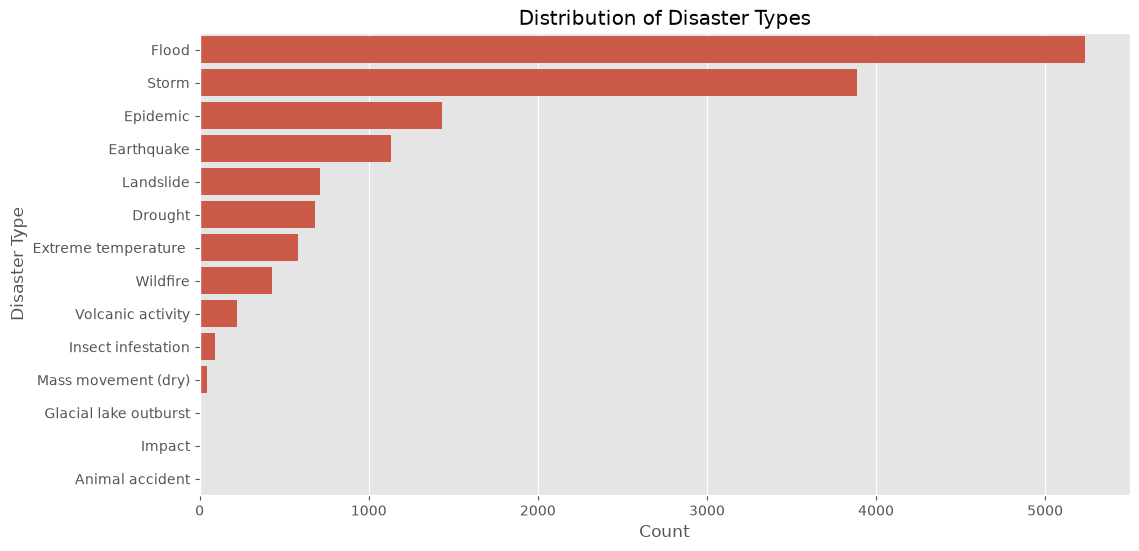

In [7]:
plt.figure(figsize=(12,6))

sns.countplot(
    y='Disaster_Type',
    data=df,
    order=df['Disaster_Type'].value_counts().index
)

plt.title("Distribution of Disaster Types")
plt.xlabel("Count")
plt.ylabel("Disaster Type")

plt.show()

In [8]:
plt.savefig("../images/disaster_type_distribution.png")

<Figure size 640x480 with 0 Axes>

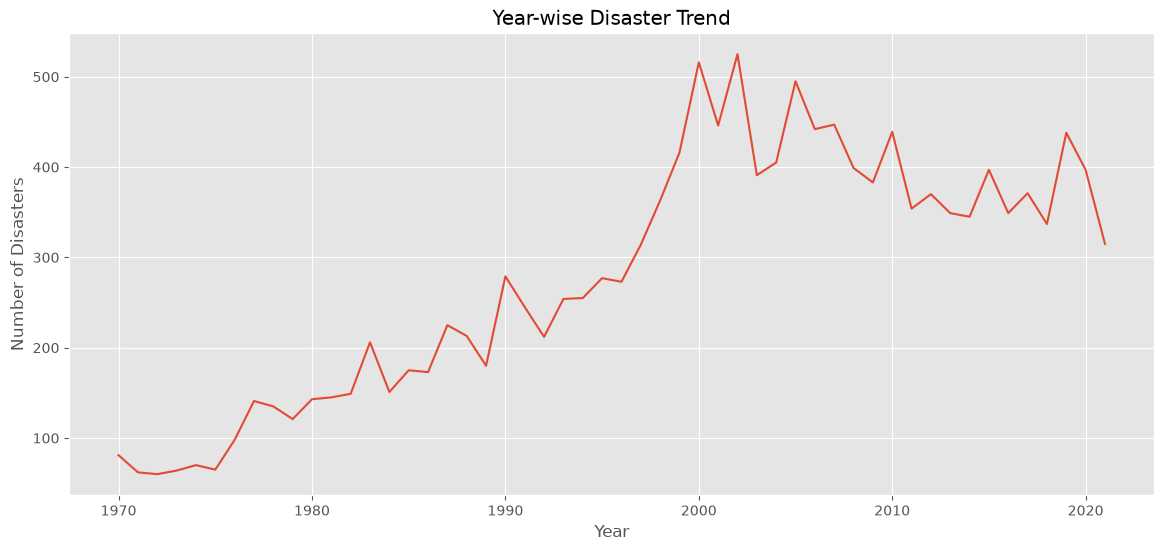

In [9]:
yearly_disasters = df.groupby('Year').size()

plt.figure(figsize=(14,6))

yearly_disasters.plot()

plt.title("Year-wise Disaster Trend")
plt.xlabel("Year")
plt.ylabel("Number of Disasters")

plt.show()

In [10]:
plt.savefig("../images/yearly_trend.png")


<Figure size 640x480 with 0 Axes>

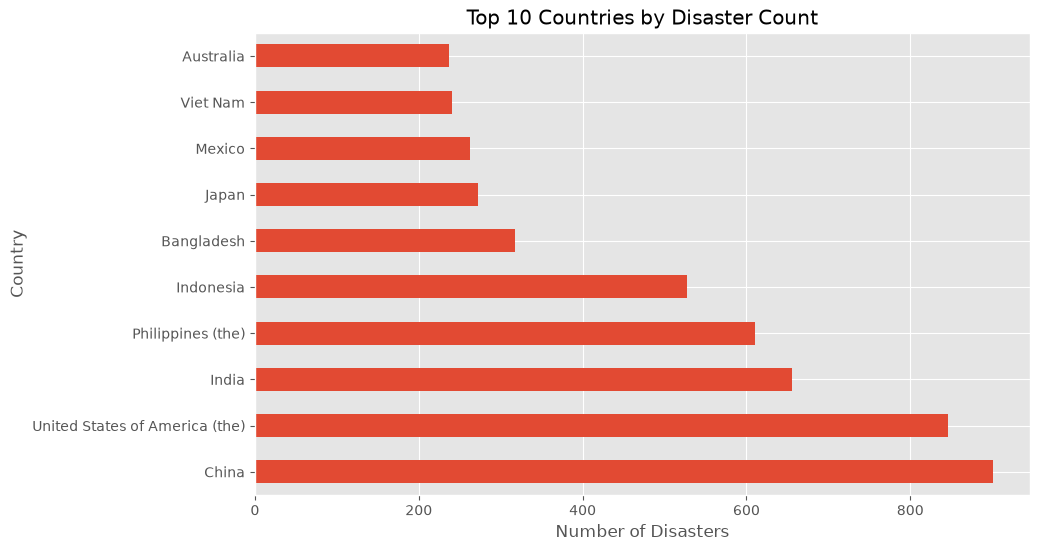

In [11]:
top_countries = df['Country'].value_counts().head(10)

plt.figure(figsize=(10,6))

top_countries.plot(kind='barh')

plt.title("Top 10 Countries by Disaster Count")
plt.xlabel("Number of Disasters")

plt.show()

In [12]:
plt.savefig("../images/top_countries.png")

<Figure size 640x480 with 0 Axes>

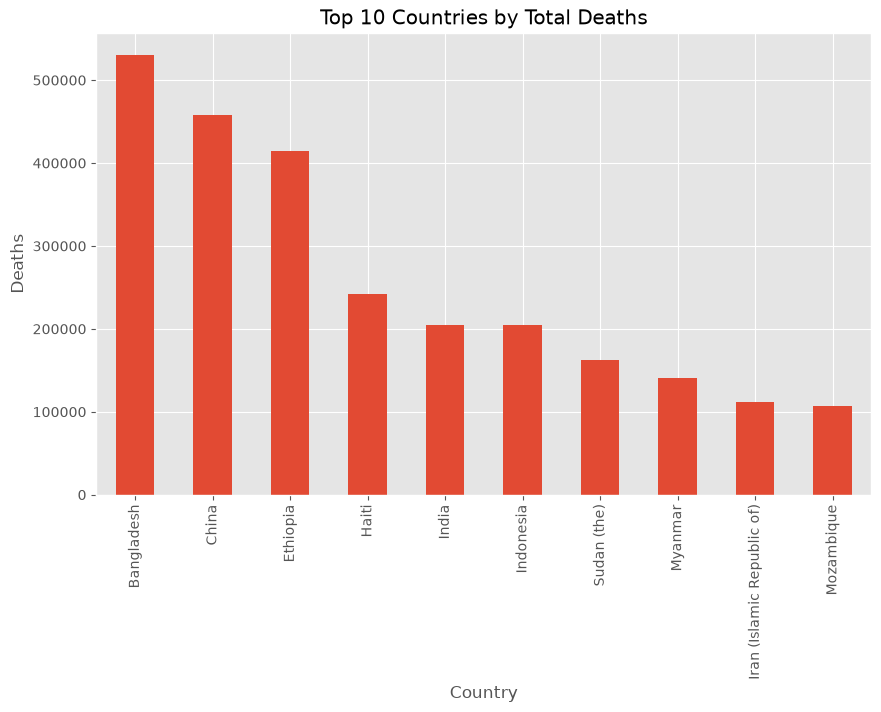

In [13]:
top_deaths = (
    df.groupby('Country')['Deaths']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

top_deaths.plot(kind='bar')

plt.title("Top 10 Countries by Total Deaths")
plt.ylabel("Deaths")

plt.show()

In [14]:
plt.savefig("../images/top_deaths.png")

<Figure size 640x480 with 0 Axes>

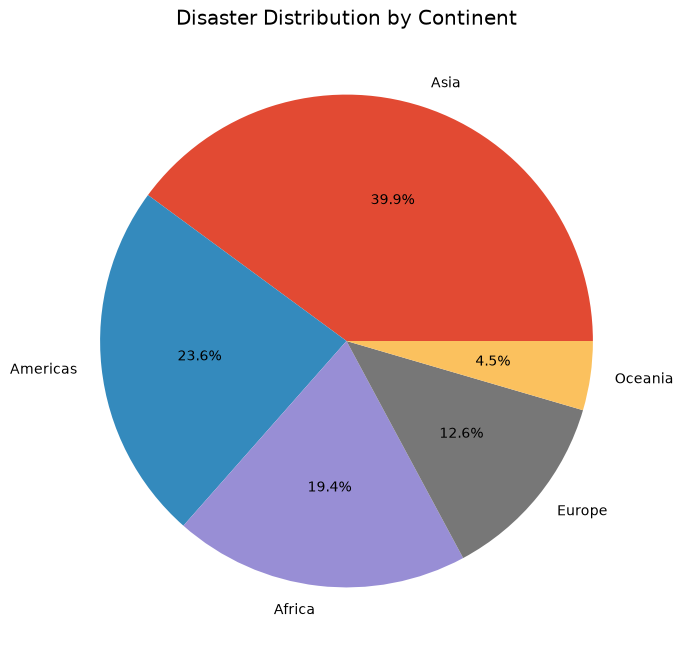

In [15]:
plt.figure(figsize=(8,8))

df['Continent'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel("")
plt.title("Disaster Distribution by Continent")

plt.show()

In [16]:
plt.savefig("../images/continent_distribution.png")

<Figure size 640x480 with 0 Axes>

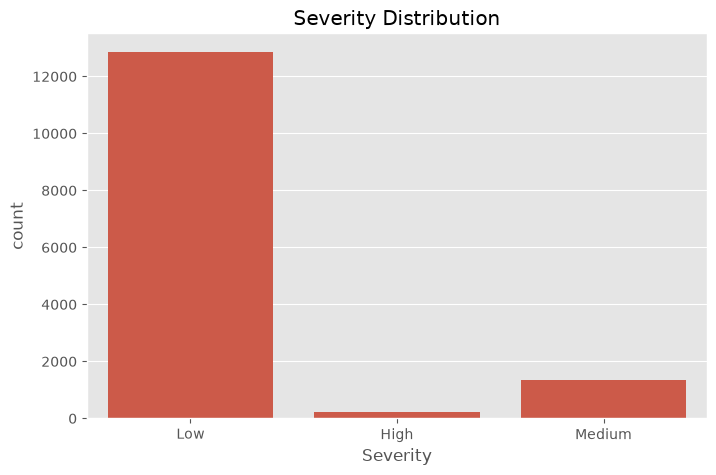

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Severity',
    data=df
)

plt.title("Severity Distribution")

plt.show()

In [18]:
plt.savefig("../images/severity_distribution.png")

<Figure size 640x480 with 0 Axes>

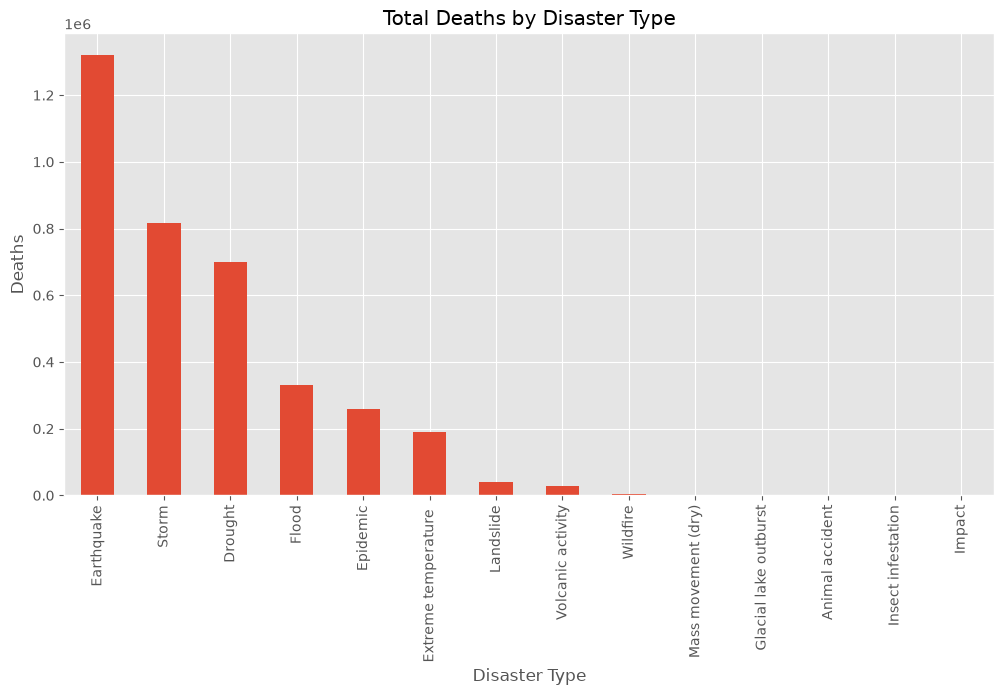

In [19]:
death_by_type = (
    df.groupby('Disaster_Type')['Deaths']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

death_by_type.plot(kind='bar')

plt.title("Total Deaths by Disaster Type")
plt.xlabel("Disaster Type")
plt.ylabel("Deaths")

plt.show()

In [20]:
plt.savefig("../images/deaths_by_disaster_type.png")

<Figure size 640x480 with 0 Axes>

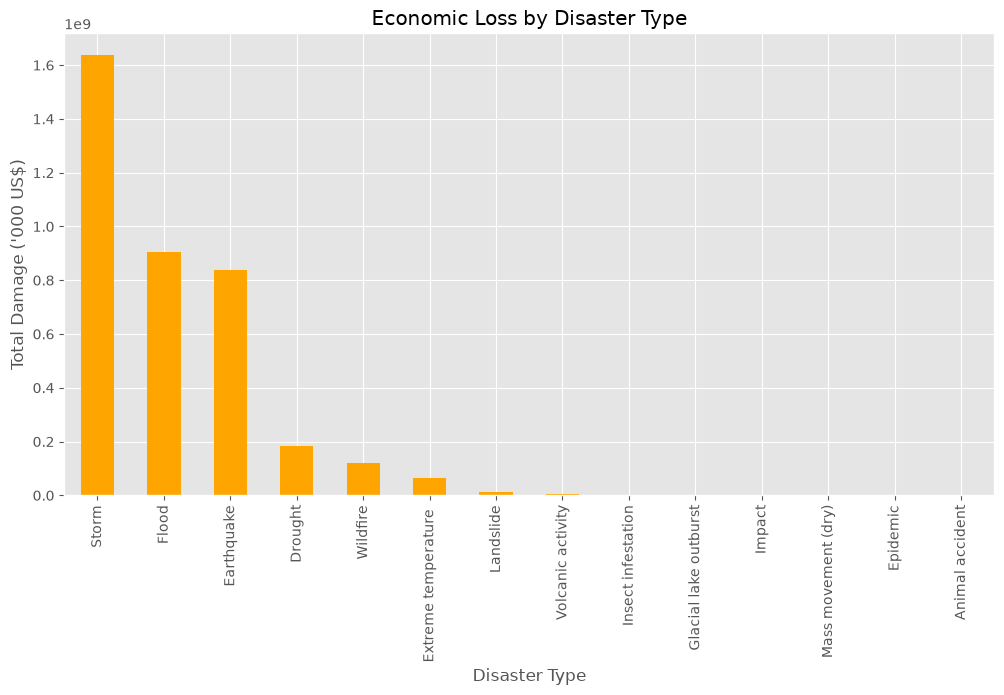

In [21]:
damage_by_type = (
    df.groupby('Disaster_Type')['Total_Damages_USD']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

damage_by_type.plot(kind='bar', color='orange')

plt.title("Economic Loss by Disaster Type")
plt.xlabel("Disaster Type")
plt.ylabel("Total Damage ('000 US$)")

plt.show()

In [22]:
plt.savefig("../images/damage_by_disaster_type.png")

<Figure size 640x480 with 0 Axes>

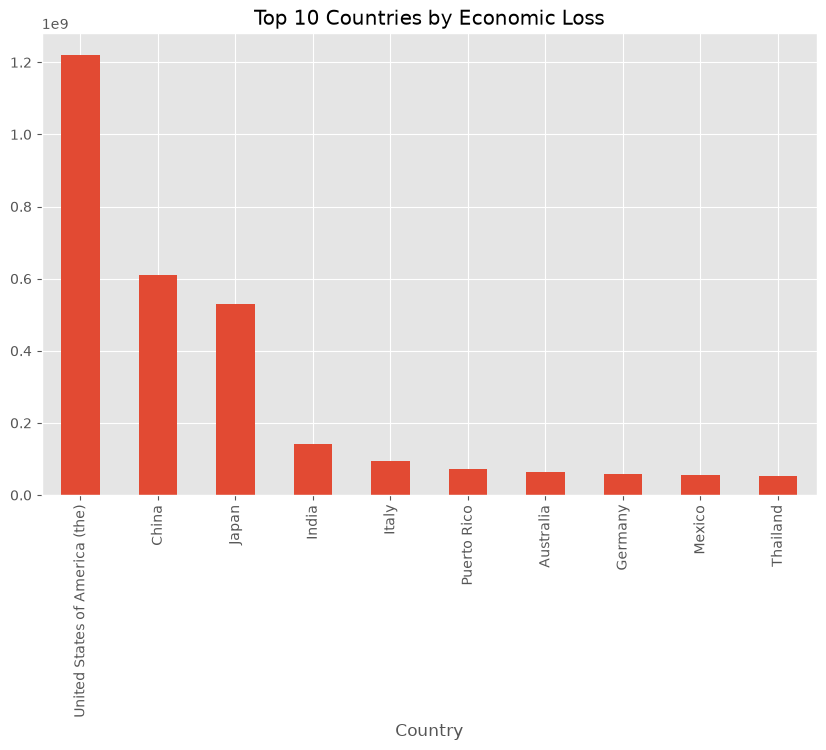

In [23]:
top_damage = (
    df.groupby('Country')['Total_Damages_USD']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

top_damage.plot(kind='bar')

plt.title("Top 10 Countries by Economic Loss")

plt.show()

In [24]:
plt.savefig("../images/top_damage_countries.png")

<Figure size 640x480 with 0 Axes>

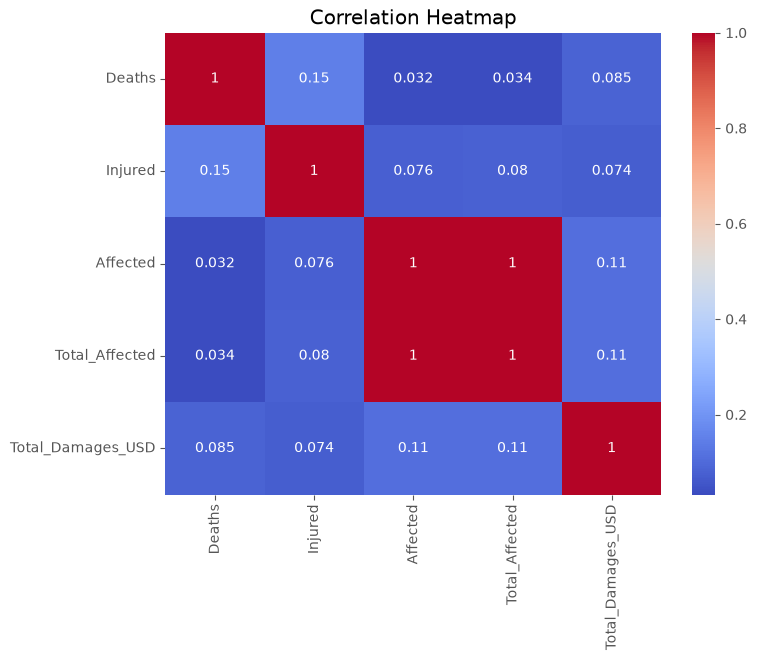

In [25]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[['Deaths',
        'Injured',
        'Affected',
        'Total_Affected',
        'Total_Damages_USD']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [26]:
plt.savefig("../images/correlation_heatmap.png")

<Figure size 640x480 with 0 Axes>

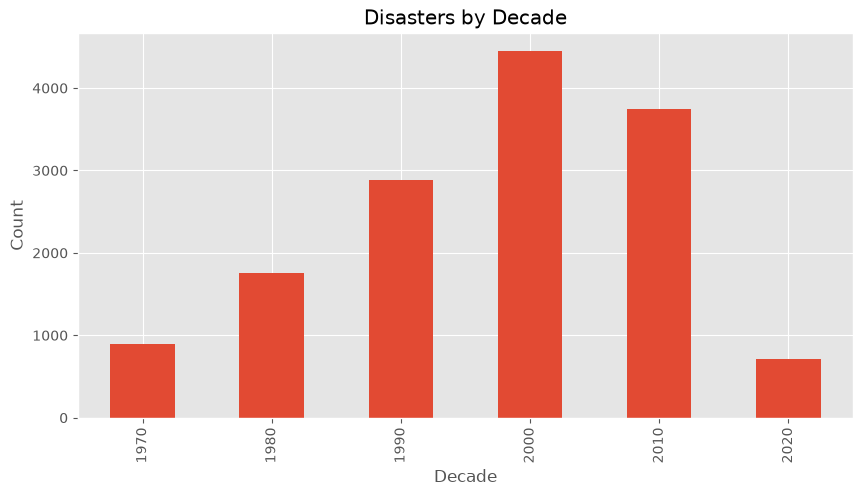

In [27]:
decade_count = df.groupby('Decade').size()

plt.figure(figsize=(10,5))

decade_count.plot(kind='bar')

plt.title("Disasters by Decade")
plt.xlabel("Decade")
plt.ylabel("Count")

plt.show()

In [28]:
plt.savefig("../images/decade_trend.png")

<Figure size 640x480 with 0 Axes>